<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/Notebook05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 05: SHAP Explainability Analysis
Applies SHAP (SHapley Additive exPlanations) to the trained Random Forest model to identify which NSL-KDD features most influence attack detection.

In [ ]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
!pip install shap -q
import numpy as np, pandas as pd, joblib, shap, matplotlib.pyplot as plt, warnings, pickle
warnings.filterwarnings('ignore')
BASE = '/content/drive/MyDrive/xai-ids'
print(f'✅ SHAP {shap.__version__}')

Mounted at /content/drive
✅ SHAP 0.51.0


In [ ]:
# CELL 2
rf_model = joblib.load(f'{BASE}/results/models/random_forest.pkl')
data = joblib.load(f'{BASE}/data/processed/nsl_kdd_processed.pkl')
X_test = data['X_test']; y_test = data['y_test']
feature_names = data['feature_names']
print(f'✅ Model loaded | features: {len(feature_names)} | first 5: {feature_names[:5]}')

np.random.seed(42)
idx200 = np.random.choice(len(X_test), 200, replace=False)
X_sample = X_test[idx200]; y_sample = y_test[idx200]
print(f'✅ Using 200 samples | attacks in sample: {y_sample.sum()}')

✅ Model loaded | features: 41 | first 5: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes']
✅ Using 200 samples | attacks in sample: 107


In [ ]:
# CELL 3
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)
print(f'✅ SHAP values computed')
print(f'   type: {type(shap_values)} | shape[0]: {np.array(shap_values[0]).shape}')

✅ SHAP values computed
   type: <class 'numpy.ndarray'> | shape[0]: (41, 2)


In [ ]:
# CELL 4
shap_class1 = np.array(shap_values[1]) if isinstance(shap_values, list) else np.array(shap_values)
if shap_class1.ndim == 3: shap_class1 = shap_class1[:,:,0]
feat_names = feature_names[:shap_class1.shape[1]]

importance = np.abs(shap_class1).mean(axis=0)
importance_df = pd.DataFrame({'feature':feat_names,'importance':importance}).sort_values('importance',ascending=False)

print('TOP 10 FEATURES (SHAP):')
for r, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    print(f'  {r:2d}. {row["feature"]:35s} {row["importance"]:.4f}')
importance_df.to_csv(f'{BASE}/results/metrics/shap_importance.csv', index=False)
print('✅ Importance saved')

TOP 10 FEATURES (SHAP):
   1. src_bytes                           0.0970
   2. dst_bytes                           0.0650
   3. dst_host_srv_count                  0.0424
   4. flag                                0.0391
   5. dst_host_same_srv_rate              0.0339
   6. logged_in                           0.0316
   7. same_srv_rate                       0.0292
   8. count                               0.0286
   9. diff_srv_rate                       0.0243
  10. dst_host_diff_srv_rate              0.0237
✅ Importance saved


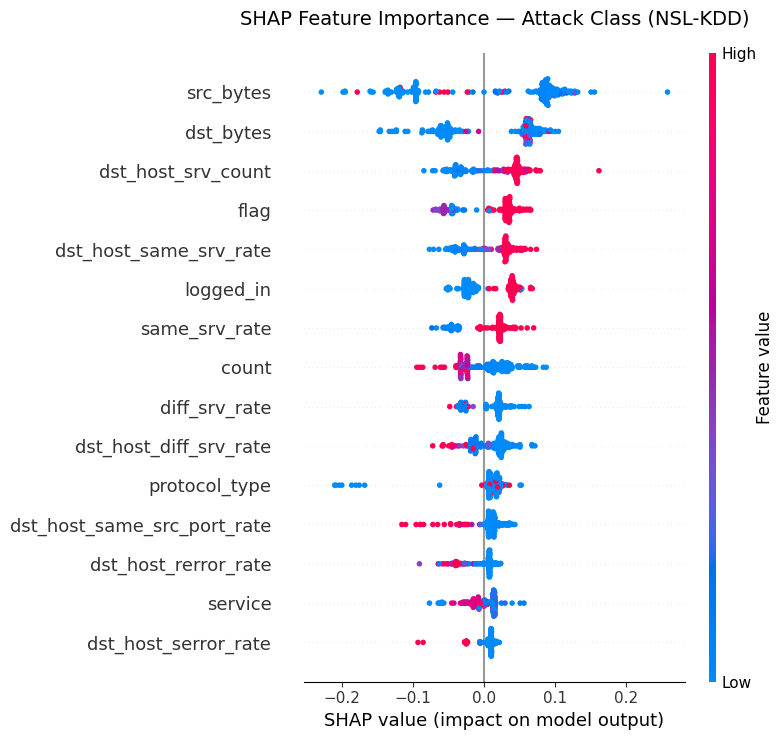

✅ Beeswarm saved


In [ ]:
# CELL 5 — Beeswarm summary
plt.figure(figsize=(12,9))
shap.summary_plot(shap_class1, X_sample, feature_names=feat_names, max_display=15, show=False)
plt.title('SHAP Feature Importance — Attack Class (NSL-KDD)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show(); print('✅ Beeswarm saved')

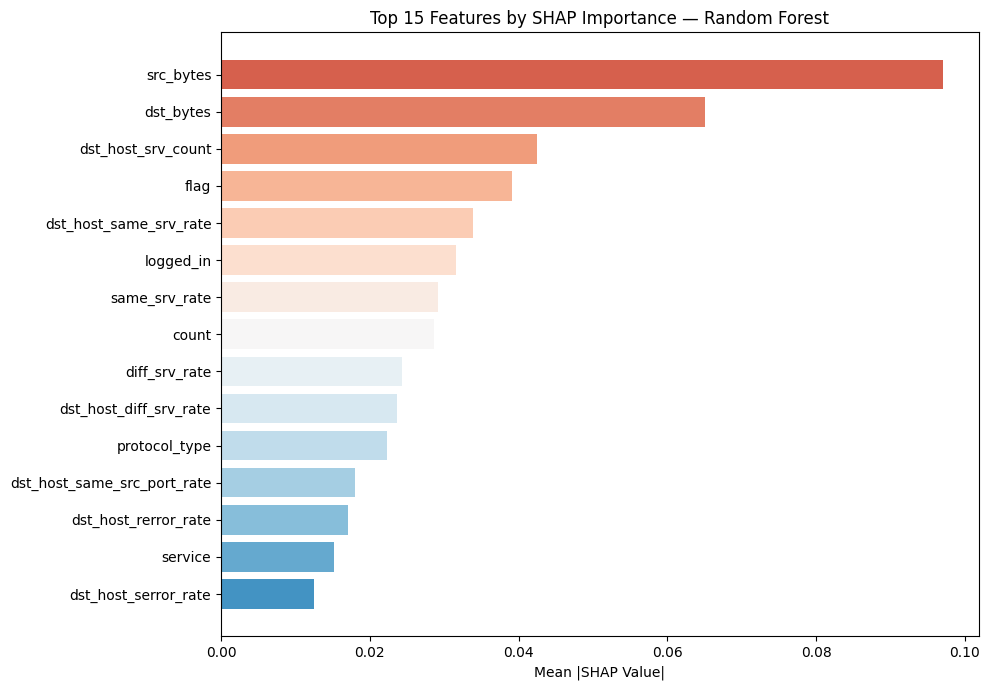

✅ Bar plot saved


In [ ]:
# CELL 6 — Bar plot
top15 = importance_df.head(15)
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(range(15), top15['importance'].values[::-1], color=plt.cm.RdBu_r(np.linspace(0.2,0.8,15)))
ax.set_yticks(range(15)); ax.set_yticklabels(top15['feature'].values[::-1])
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 15 Features by SHAP Importance — Random Forest')
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show(); print('✅ Bar plot saved')

In [ ]:
# CELL 7 — Individual explanations
attack_idx  = np.where(y_sample == 1)[0]
normal_idx  = np.where(y_sample == 0)[0]

for indices, label_str in [(attack_idx,'Attack'),(normal_idx,'Normal')]:
    if len(indices) == 0: continue
    i = indices[0]
    pred  = rf_model.predict(X_sample[i].reshape(1,-1))[0]
    proba = rf_model.predict_proba(X_sample[i].reshape(1,-1))[0]
    print(f'\nSample {i} | Actual: {label_str} | Pred: {"Attack" if pred==1 else "Normal"} | Conf: {max(proba):.2%}')
    top5 = np.argsort(np.abs(shap_class1[i]))[-5:][::-1]
    for fi in top5:
        v = float(shap_class1[i][fi])
        print(f'   {feat_names[fi]:35s}: {"INCREASES" if v>0 else "DECREASES"} by {abs(v):.4f}')


Sample 1 | Actual: Attack | Pred: Attack | Conf: 100.00%
   src_bytes                          : DECREASES by 0.1216
   dst_bytes                          : DECREASES by 0.0603
   flag                               : DECREASES by 0.0547
   same_srv_rate                      : DECREASES by 0.0401
   dst_host_srv_count                 : DECREASES by 0.0375

Sample 0 | Actual: Normal | Pred: Normal | Conf: 99.47%
   src_bytes                          : INCREASES by 0.1017
   dst_bytes                          : INCREASES by 0.0754
   logged_in                          : INCREASES by 0.0482
   flag                               : INCREASES by 0.0426
   dst_host_srv_count                 : INCREASES by 0.0297


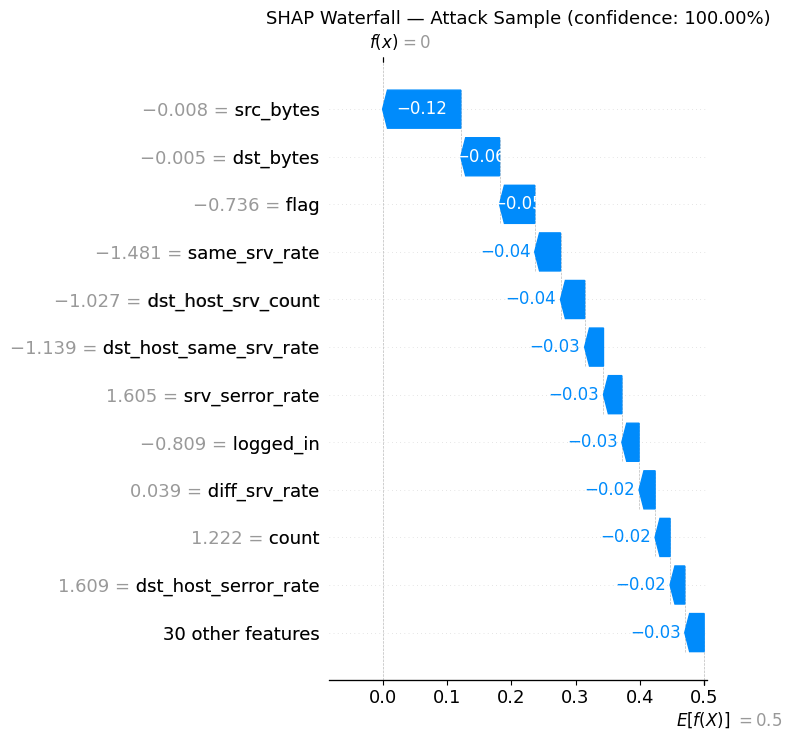

✅ Waterfall saved


In [ ]:
# CELL 8 — Waterfall plot
if len(attack_idx) > 0:
    i = attack_idx[0]
    ev = explainer.expected_value
    base_val = float(np.asarray(ev).flat[1]) if isinstance(ev, (list, np.ndarray)) else float(ev)

    exp_obj = shap.Explanation(
        values=shap_class1[i], base_values=base_val,
        data=X_sample[i], feature_names=feat_names
    )
    shap.plots.waterfall(exp_obj, max_display=12, show=False)
    conf = rf_model.predict_proba(X_sample[i].reshape(1,-1))[0][1]
    plt.title(f'SHAP Waterfall — Attack Sample (confidence: {conf:.2%})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{BASE}/results/figures/shap_waterfall.png', dpi=300, bbox_inches='tight')
    plt.show(); print('✅ Waterfall saved')

In [ ]:
# CELL 9 — Save
shap_data = {
    'shap_values': shap_values, 'shap_class1': shap_class1,
    'expected_value': explainer.expected_value,
    'data': X_sample, 'labels': y_sample,
    'feature_names': feat_names, 'sample_indices': idx200
}
with open(f'{BASE}/results/shap_values.pkl','wb') as f:
    pickle.dump(shap_data, f)
print(f'✅ SHAP saved — {shap_class1.shape[0]} samples, {len(feat_names)} named features')

✅ SHAP saved — 200 samples, 41 named features
